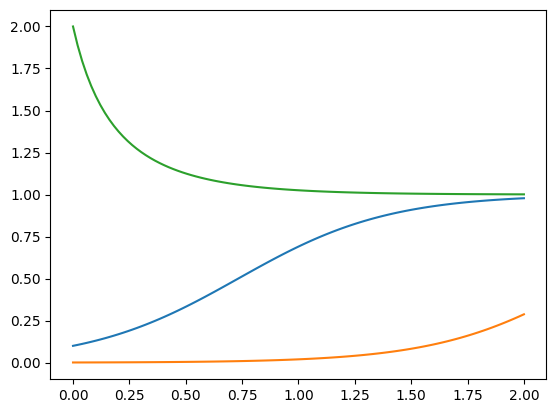

In [1]:
import numpy as np
from matplotlib import pyplot as plt

def f(x,u,lambda0=3.,lambda1=1.):
    return lambda0 * u * (1. - u / lambda1)

def u(x,lambda0=3.,lambda1=1., u0=0.1):
    return lambda1 * np.exp(lambda0 * x) * u0 / (lambda1 + u0 * (np.exp(lambda0 * x) - 1))

x = np.linspace(0,2,100)
y = u(x)
y2 = u(x, u0=1e-3)
y3 = u(x, u0=2.)

plt.figure()
plt.plot(x,y, label="$g_0=0.1$")
plt.plot(x,y2,label="$g_0=0.001$")
plt.plot(x,y3,label="$g_0=2.0")
plt.show()

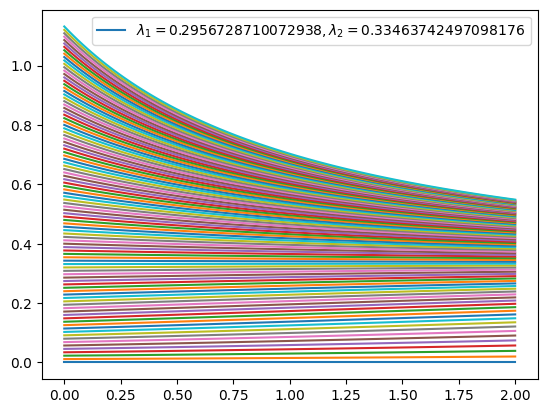

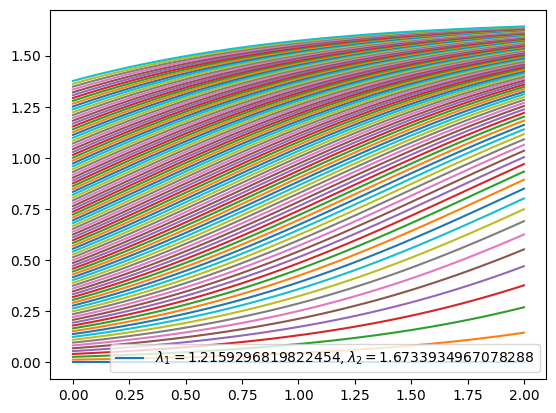

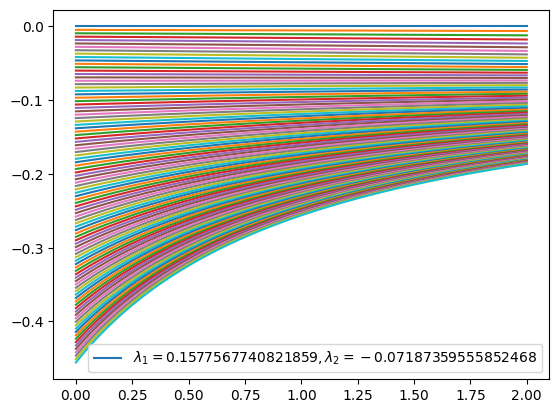

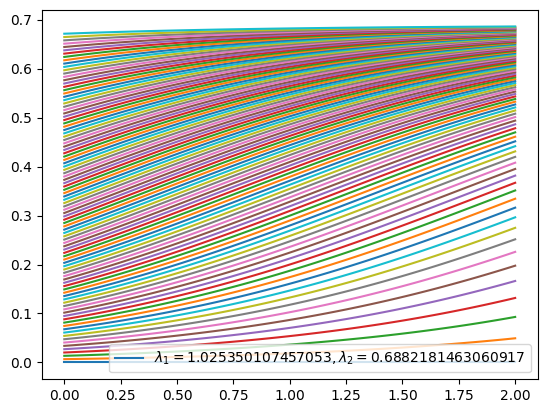

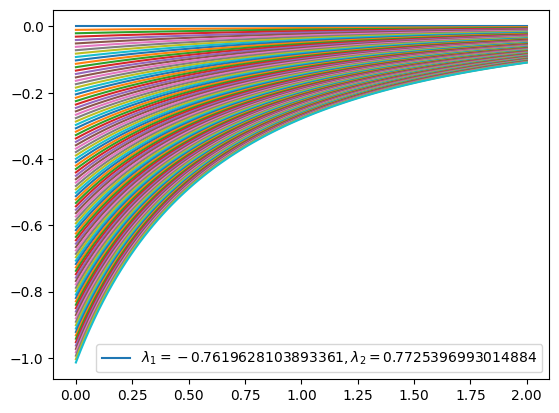

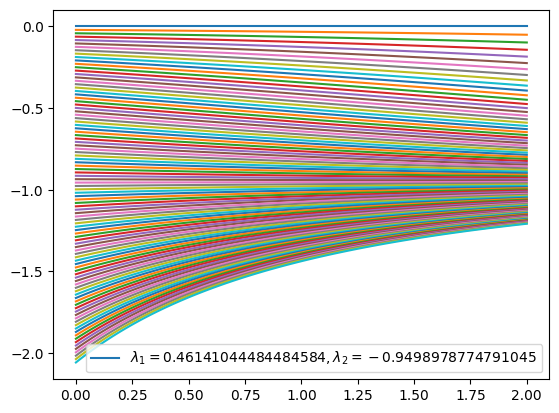

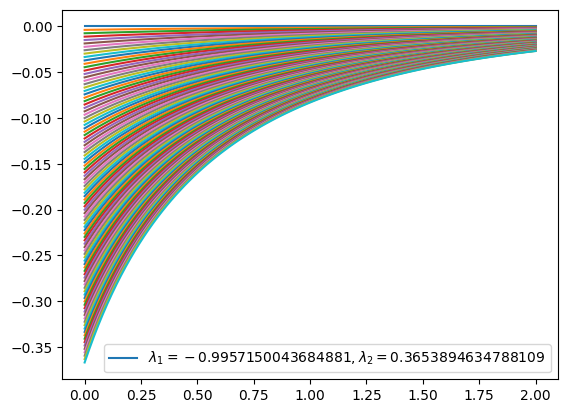

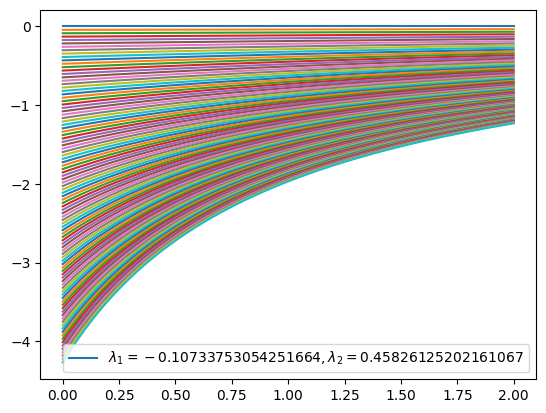

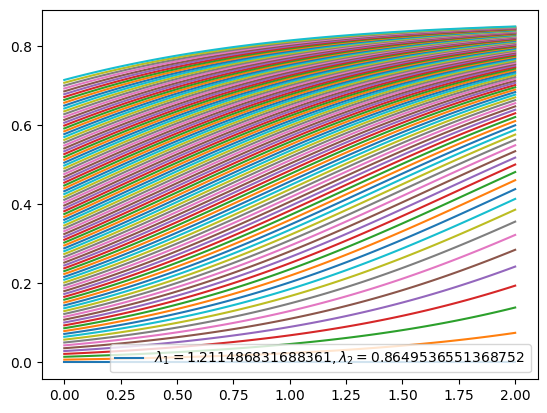

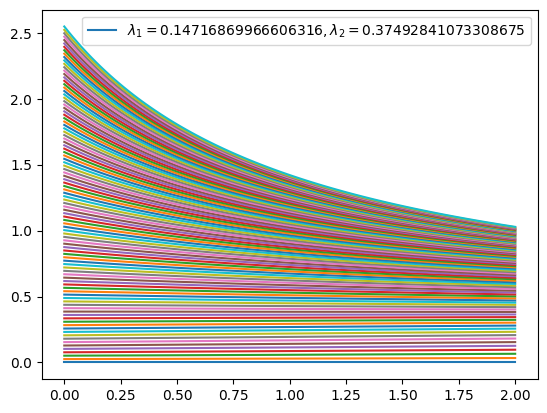

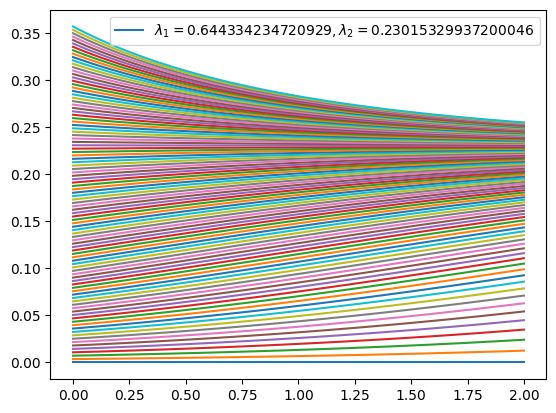

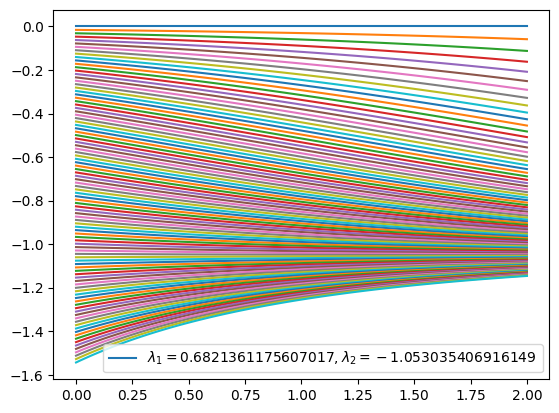

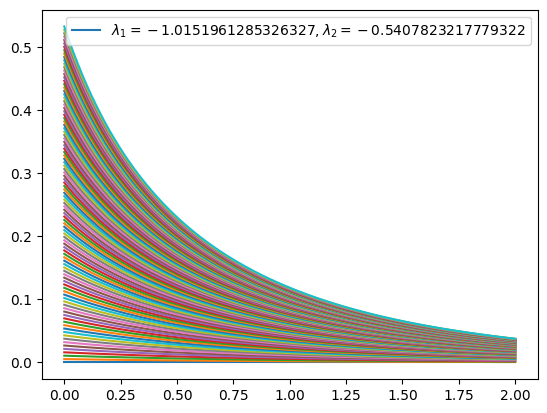

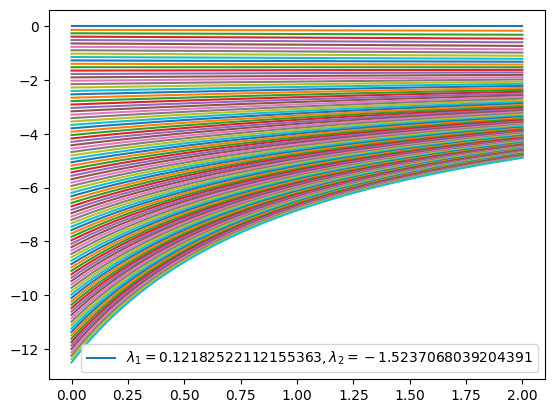

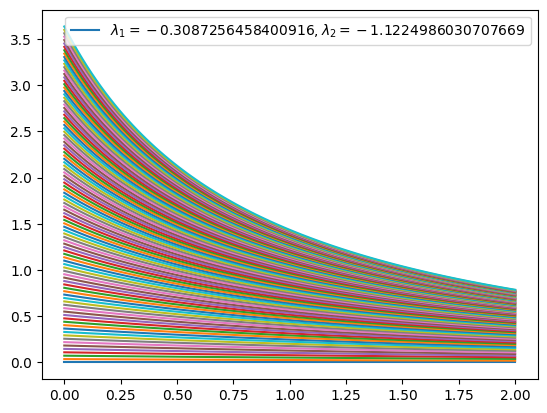

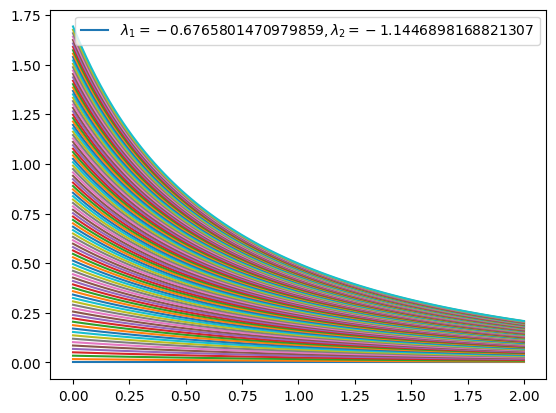

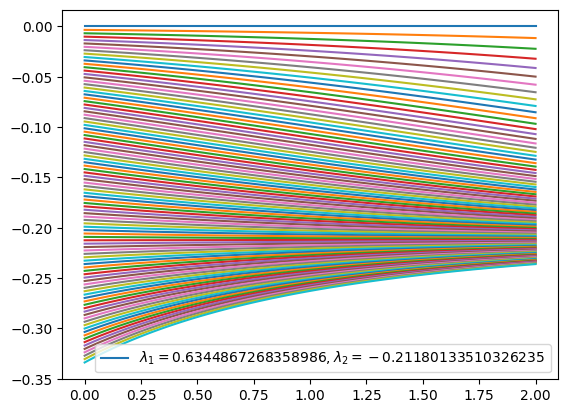

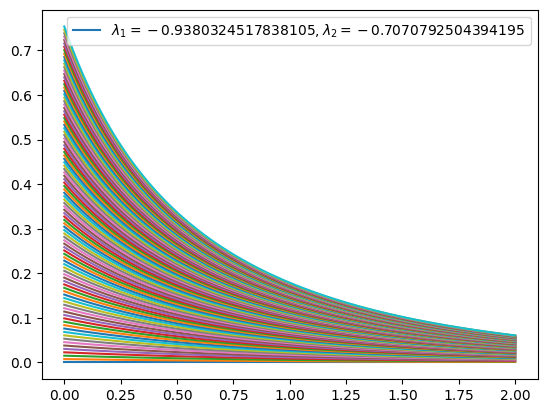

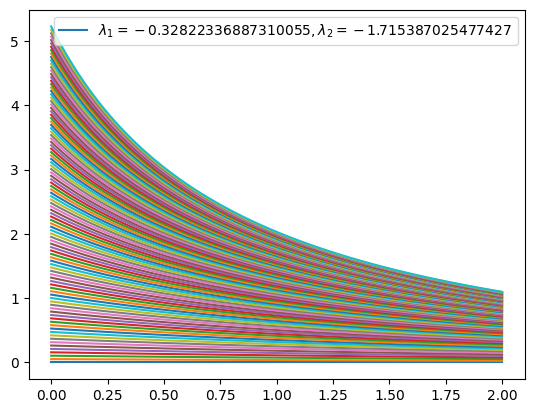

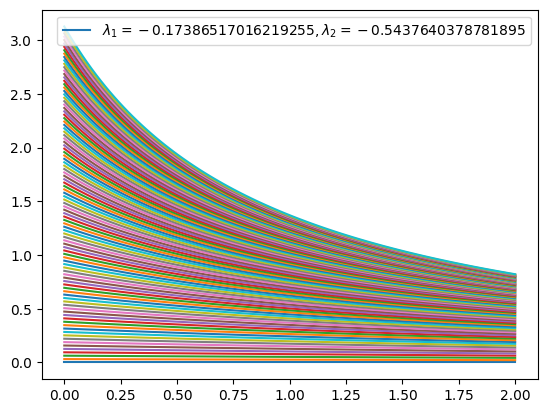

In [2]:
def f(x,u,lambda0=3.,lambda1=1.):
    return lambda0 * u * (1. - u / lambda1)

def u(x,lambda0=3.,lambda1=1., u0=0.1):
    return lambda1 * np.exp(lambda0 * x) * u0 / (lambda1 + u0 * (np.exp(lambda0 * x) - 1))


x = np.linspace(0,2,100)
params = np.random.randn(20, 2)

for (lambda0, lambda1) in params:
    plt.figure()
    for g in np.linspace(0, lambda1/lambda0, 100):
        y = u(x, lambda0=lambda0, lambda1=lambda1, u0=g)    
        plt.plot(x,y)
    plt.legend([f'$\lambda_1 = {lambda0}, \lambda_2 = {lambda1}$'])
    plt.show()


In [ ]:
x = np.linspace(0,2,100)
y = u(x, u0=-0.1)

plt.figure()
plt.plot(x,y, label="$g_0=-0.1$")
plt.show()

In [ ]:
from motion_code import MotionCode
from data_processing import load_data, process_data_for_motion_codes

name = 'logistic_ode'
Y_train = np.zeros((60, 1, 100))
g = np.concatenate([np.linspace(-0.001, 0.001, 20), np.linspace(0.1, 0.5, 20), np.linspace(1.,2.,20)])
labels_train = np.concatenate([[0]*20, [1]*20, [2]*20])
for i in range(len(g)):
    Y_train[i, 0, :] = u(x, u0=g[i])
Y_train = Y_train + np.random.normal(size=Y_train.shape) * 0.03 * np.max(np.abs(Y_train))

# Then we process the data for motion code model and generate X-variable, which is needed for training.
X_train, Y_train, labels_train = process_data_for_motion_codes(Y_train, labels_train)


print(X_train.shape, Y_train.shape, labels_train.shape)
Y = Y_train[labels_train==0, :]
for i in range(20):
    plt.plot(x, Y[i],c='blue')
plt.show()


In [ ]:
# Next we build the default motion code model for both forecasting and classification
model = MotionCode(m=10, Q=1, latent_dim=3, sigma_y=0.01)

# Then we train model on the given X_train, Y_train, label_train set and saved it to a file named test_model.
model_path = 'saved_models/' + 'test_model'
#model.fit(X_train, Y_train, labels_train, model_path)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

model.load(model_path)
# We predict on test time horizon [1, 1.2] with 20 time steps
test_time_horizon = np.linspace(0, 1, 100)

# label is the label for the stochastic process we predict
mean, covar = model.forecast_predict(test_time_horizon, label=1)
std = np.sqrt(np.diag(covar)).reshape(-1)
print(std)

# We plot all the time series on the horizon [0, 1]
X = X_train[labels_train==1, :]
Y = Y_train[labels_train==1, :]
plt.plot(X[0], Y[0], c='blue', lw=0.5, zorder=1, label='$u(x)$')
for i in range(1, X.shape[0]):
    plt.plot(X[i], Y[i], c='blue', lw=0.5, zorder=1)

# Then we plot our prediction with uncertainty on test time horizon = [1, 1.2]
plt.plot(test_time_horizon, mean, c='green', lw=2, zorder=1, label='Mean prediction')
plt.fill_between(test_time_horizon, mean+2*std, mean-2*std, color='red', alpha=0.1, zorder=1)

# Plot setting and plot show
handle_list, _ = plt.gca().get_legend_handles_labels()
handle_list.append(mpatches.Patch(color='green', label='Uncertainty region'))
plt.legend(handles=handle_list, fontsize='10', loc ="lower left")
plt.ylim(1.1 * np.min(Y), 1.1 * np.max(Y))
plt.title('Time series forecasting by motion code')
plt.show()

In [ ]:
Y_test = np.zeros((11, 1, 10))
np.random.seed(9999)
g_test = np.random.randn((10)) * 0.5 + 0.8
g_test = np.append(g_test, [0.01])
x_test = np.linspace(0,1,10)
for i in range(len(g_test)):
    Y_test[i, 0, :] = u(x_test, u0=g_test[i])
labels_test = [0] * 11
X_test, Y_test, labels_test = process_data_for_motion_codes(Y_test, labels_test)

for i in range(len(g_test)):
    plt.plot(x_test, Y_test[i],c='blue')
plt.show()

print(g_test)

In [ ]:
num_test = labels_test.shape[0]
predicted_labels = []
for ind in range(num_test):
    predicted_labels.append(model.classify_predict(X_test[ind], Y_test[ind]))
print('True label:', list(labels_test))
print('Predicted label:', predicted_labels)

In [ ]:
from sparse_gp import q, jitter, spectral_kernel, sigmoid


def qq(X_test, X_obs, Y_obs, X_m, kernel_params, mu_m, A_m, K_mm_inv):
    """
    Distribution prediction for a new collection of time variables
    """
    sigma, alpha = kernel_params
    K_ss = spectral_kernel(X_test, X_test, sigma, alpha)
    K_sm = spectral_kernel(X_test, X_m, sigma, alpha)
    K_ms = K_sm.T
    K_om = spectral_kernel(X_obs, X_m, sigma, alpha)
    K_mo = K_om.T
    K_os = spectral_kernel(X_obs, X_test, sigma, alpha)
    K_so = K_os.T
    K_oo = spectral_kernel(X_obs, X_obs, sigma, alpha) + jitter(X_obs.shape[0])
    K_oo_inv = np.linalg.inv(K_oo) 
    f_q = (K_so @ K_oo_inv).dot(Y_obs -  (K_om @ K_mm_inv).dot(mu_m)) + (K_sm @ K_mm_inv).dot(mu_m)
    # f_qq = (K_sm @ K_mm_inv).dot(mu_m)
    f_q_cov = K_ss - K_sm @ K_mm_inv @ K_ms + K_sm @ K_mm_inv @ A_m @ K_mm_inv @ K_ms \
        - K_so @ K_oo_inv @ K_os + K_so @ K_oo_inv @ (K_oo + 0.0001 * K_os @ K_so) @ K_oo_inv @ K_os 

    return f_q, f_q_cov

# redo the problem by recompute time stamps
for ind in range(num_test):
    k = predicted_labels[ind]
    plt.plot(X_test[ind], Y_test[ind], 'o-', lw=2, zorder=1, label='True solution')
    mean, covar = qq(X_train[0], X_test[ind], Y_test[ind], sigmoid(model.X_m @ model.Z[k]), model.kernel_params[k], model.mu_ms[k], model.A_ms[k], model.K_mm_invs[k])
    print(mean)
    std = np.sqrt(np.diag(covar)).reshape(-1)
    plt.plot(test_time_horizon, mean, c='red', lw=2, zorder=1, label='Mean prediction ')
    plt.fill_between(test_time_horizon, mean+2*std, mean-2*std, color='red', alpha=0.1, zorder=1)
    mean, covar = q(X_train[0], sigmoid(model.X_m @ model.Z[k]), model.kernel_params[k], model.mu_ms[k], model.A_ms[k], model.K_mm_invs[k])
    print(mean)
    std = np.sqrt(np.diag(covar)).reshape(-1)
    plt.plot(test_time_horizon, mean, c='green', lw=2, zorder=1, label='Mean prediction (w.o. filter)')
    plt.fill_between(test_time_horizon, mean+2*std, mean-2*std, color='green', alpha=0.1, zorder=1)
    # Plot setting and plot show
    handle_list, _ = plt.gca().get_legend_handles_labels()
    handle_list.append(mpatches.Patch(color='red', label='Uncertainty region'))
    handle_list.append(mpatches.Patch(color='green', label='Uncertainty region'))
    plt.legend(handles=handle_list, fontsize='10', loc ="lower left")
    plt.show()
    break

In [ ]:
mse = []
x= np.linspace(0,1,1000)
for ind in range(num_test):
    k = predicted_labels[ind]
    y_gt =  u(X_train[0], u0=g_test[ind])
    y, _ = qq(X_train[0], X_test[ind], Y_test[ind], sigmoid(model.X_m @ model.Z[k]), model.kernel_params[k], model.mu_ms[k], model.A_ms[k], model.K_mm_invs[k])
    mse.append(np.max(np.abs(y-y_gt)))
print(np.mean(mse))